In [1]:
#  Install & Imports ──────────────────────────────────────────────
!pip install -q newspaper3k nltk scikit-learn vaderSentiment transformers torch \
             sentence-transformers lxml_html_clean

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests

from newspaper import Article
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

print("All imports successful.")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 43.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.1/211.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 1.9 MB/s eta 0:00:00
All imports successful.


In [2]:
#  Load Models ────────────────────────────────────────────────────
# BART for summarization
bart_tokenizer = AutoTokenizer.from_pretrained('facebook/bart-large-cnn')
bart_model     = AutoModelForSeq2SeqLM.from_pretrained('facebook/bart-large-cnn')

def bart_summarize(text, max_length=200, min_length=60):
    inputs = bart_tokenizer(
        text, return_tensors='pt', max_length=1024, truncation=True
    )
    ids = bart_model.generate(
        inputs['input_ids'],
        max_length=max_length,
        min_length=min_length,
        length_penalty=2.0,
        num_beams=4,
        early_stopping=True
    )
    return bart_tokenizer.decode(ids[0], skip_special_tokens=True)

# Sentence embeddings for semantic similarity
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# Emotion classifier
emo_pipe = pipeline(
    'text-classification',
    model='j-hartmann/emotion-english-distilroberta-base',
    top_k=None
)

print("All models loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

All models loaded.


In [4]:
#  Extract Articles ───────────────────────────────────────────────

urls = {
    "NYT":     "https://archive.ph/newest/https://www.nytimes.com/2024/05/14/climate/climate-change-extreme-weather.html",
    "FoxNews": "https://www.foxnews.com/science/climate-change-weather-impact-explained"
}

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
articles = {}

for source, url in urls.items():
    response = requests.get(url, headers=headers)
    art = Article(url)
    art.set_html(response.text)
    art.parse()
    art.nlp()
    articles[source] = art
    print(f"[{source}] Status: {response.status_code} | Words: {len(art.text.split())} | Title: {art.title}")

nyt_text = articles["NYT"].text
fox_text = articles["FoxNews"].text

print(f"\n--- NYT Preview ---\n{nyt_text[:300]}")
print(f"\n--- FoxNews Preview ---\n{fox_text[:300]}")

[NYT] Status: 429 | Words: 83 | Title: archive.ph
[FoxNews] Status: 404 | Words: 52 | Title: Fox News

--- NYT Preview ---
Completing the CAPTCHA proves you are a human and gives you temporary access to the web property.

What can I do to prevent this in the future?

If you are on a personal connection, like at home, you can run an anti-virus scan on your device to make sure it is not infected with malware.

If you are 

--- FoxNews Preview ---
This material may not be published, broadcast, rewritten, or redistributed. Â©2021 FOX News Network, LLC. All rights reserved. Quotes displayed in real-time or delayed by at least 15 minutes. Market data provided by Factset. Powered and implemented by FactSet Digital Solutions. Legal Statement. Mutu


In [5]:
# Mirrors: Extract Articles (Open-Access URLs) ────────────────────────────

# Article 1: WMO (mainstream science, mirrors NYT angle)
# Article 2: Heritage Foundation (skeptic/conservative, mirrors FoxNews angle)

urls = {
    "WMO (Mainstream)": "https://wmo.int/media/news/climate-change-impacts-grip-globe-2024",
    "Heritage (Skeptic)": "https://www.heritage.org/climate/commentary/climate-change-the-science-doesnt-support-the-heated-rhetoric"
}

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
articles = {}

for source, url in urls.items():
    response = requests.get(url, headers=headers)
    art = Article(url)
    art.set_html(response.text)
    art.parse()
    art.nlp()
    articles[source] = art
    print(f"[{source}]")
    print(f"  Status : {response.status_code}")
    print(f"  Title  : {art.title}")
    print(f"  Words  : {len(art.text.split())}\n")

nyt_text = articles["WMO (Mainstream)"].text
fox_text = articles["Heritage (Skeptic)"].text

print(f"--- WMO Preview ---\n{nyt_text[:300]}\n")
print(f"--- Heritage Preview ---\n{fox_text[:300]}")

[WMO (Mainstream)]
  Status : 200
  Title  : Climate change impacts grip globe in 2024
  Words  : 665

[Heritage (Skeptic)]
  Status : 200
  Title  : Climate Change: The Science Doesn’t Support the Heated Rhetoric
  Words  : 710

--- WMO Preview ---
The year 2024 is set to be the warmest on record, capping a decade of unprecedented heat fuelled by human activities, according to the World Meteorological Organization (WMO). Greenhouse gas levels continue to grow to record observed highs, locking in even more heat for the future.

“Today I can off

--- Heritage Preview ---
We are constantly reminded that we are experiencing a climate crisis, but as a climate scientist, I can tell you that’s not what the science has shown us so far. Other than modest warming, there has been little change in any kind of severe weather that can be attributed to global greenhouse gas emis


In [6]:
#  Q1 — Similarity Measurement ───────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers.util import cos_sim

# ── Method 1: TF-IDF Cosine ──
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform([nyt_text, fox_text])
cosine_sim = cosine_similarity(tfidf_matrix[0], tfidf_matrix[1])[0][0]

# ── Method 2: Sentence Embeddings (all-MiniLM-L6-v2) ──
emb_nyt = embedder.encode(nyt_text[:1000], convert_to_tensor=True)
emb_fox = embedder.encode(fox_text[:1000], convert_to_tensor=True)
semantic_sim = cos_sim(emb_nyt, emb_fox).item()

# ── Method 3: Jaccard ──
stop_words = set(stopwords.words('english'))

def jaccard(text1, text2):
    t1 = set(w.lower() for w in word_tokenize(text1) if w.isalpha() and w.lower() not in stop_words)
    t2 = set(w.lower() for w in word_tokenize(text2) if w.isalpha() and w.lower() not in stop_words)
    return len(t1 & t2) / len(t1 | t2) if t1 | t2 else 0

jaccard_sim = jaccard(nyt_text, fox_text)

print("=== SIMILARITY SCORES ===")
print(f"  TF-IDF Cosine Similarity  : {cosine_sim:.4f}")
print(f"  Sentence Embedding Cosine : {semantic_sim:.4f}")
print(f"  Jaccard Similarity        : {jaccard_sim:.4f}")
print("""
--- Interpretation ---
TF-IDF cosine: vocabulary overlap weighted by term importance.
Sentence embeddings: semantic meaning beyond exact word matches.
Jaccard: raw unique word overlap (unweighted).
""")

=== SIMILARITY SCORES ===
  TF-IDF Cosine Similarity  : 0.3086
  Sentence Embedding Cosine : 0.6074
  Jaccard Similarity        : 0.0811

--- Interpretation ---
TF-IDF cosine: vocabulary overlap weighted by term importance.
Sentence embeddings: semantic meaning beyond exact word matches.
Jaccard: raw unique word overlap (unweighted).



In [7]:
#  Q2a — Shared Topics ───────────────────────────────────────────
tfidf_topic = TfidfVectorizer(stop_words='english', max_features=30)
tfidf_topic.fit([nyt_text, fox_text])
feature_names = np.array(tfidf_topic.get_feature_names_out())

nyt_scores = tfidf_topic.transform([nyt_text]).toarray()[0]
fox_scores = tfidf_topic.transform([fox_text]).toarray()[0]

nyt_top = set(feature_names[np.argsort(nyt_scores)[-15:]])
fox_top = set(feature_names[np.argsort(fox_scores)[-15:]])
shared  = nyt_top & fox_top

print("=== SHARED TOPICS (Top-15 TF-IDF Terms) ===")
print(f"  WMO Top Terms      : {sorted(nyt_top)}")
print(f"  Heritage Top Terms : {sorted(fox_top)}")
print(f"  Shared Terms       : {sorted(shared)}")
print(f"  Overlap Count      : {len(shared)} / 15 terms")

=== SHARED TOPICS (Top-15 TF-IDF Terms) ===
  WMO Top Terms      : ['2024', '2025', 'change', 'climate', 'events', 'extreme', 'general', 'heat', 'international', 'report', 'said', 'secretary', 'weather', 'wmo', 'year']
  Heritage Top Terms : ['change', 'climate', 'co2', 'countries', 'emissions', 'gas', 'global', 'greenhouse', 'heat', 'projections', 'record', 'severe', 'warming', 'weather', 'world']
  Shared Terms       : ['change', 'climate', 'heat', 'weather']
  Overlap Count      : 4 / 15 terms


In [8]:
# Q2b — Sentiment Comparison ────────────────────────────────────
sia = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    sentences    = sent_tokenize(text)
    scores       = [sia.polarity_scores(s) for s in sentences]
    avg_compound = sum(s['compound'] for s in scores) / len(scores)
    label        = 'Positive' if avg_compound >= 0.05 else ('Negative' if avg_compound <= -0.05 else 'Neutral')
    return avg_compound, label, scores

nyt_compound, nyt_label, nyt_sent_scores = vader_sentiment(nyt_text)
fox_compound, fox_label, fox_sent_scores = vader_sentiment(fox_text)

# ── NB + SVM pseudo-labeled from VADER ──
all_sentences, all_labels = [], []
for text in [nyt_text, fox_text]:
    for sent in sent_tokenize(text):
        score = sia.polarity_scores(sent)
        if score['compound'] >= 0.05:    lbl = 'Positive'
        elif score['compound'] <= -0.05: lbl = 'Negative'
        else:                             lbl = 'Neutral'
        all_sentences.append(sent)
        all_labels.append(lbl)

vec = TfidfVectorizer(stop_words='english', max_features=500)
X   = vec.fit_transform(all_sentences)
le  = LabelEncoder()
y   = le.fit_transform(all_labels)

n = len(sent_tokenize(nyt_text))

nb_model  = MultinomialNB().fit(X, y)
svm_model = LinearSVC(max_iter=1000).fit(X, y)

def majority(preds): return max(set(preds), key=list(preds).count)

nyt_nb  = majority(le.inverse_transform(nb_model.predict(X[:n])))
fox_nb  = majority(le.inverse_transform(nb_model.predict(X[n:])))
nyt_svm = majority(le.inverse_transform(svm_model.predict(X[:n])))
fox_svm = majority(le.inverse_transform(svm_model.predict(X[n:])))

print("=== SENTIMENT COMPARISON ===")
print(f"{'Method':<20} {'WMO':<15} {'Heritage'}")
print("-" * 50)
print(f"{'VADER Label':<20} {nyt_label:<15} {fox_label}")
print(f"{'VADER Score':<20} {nyt_compound:<15.4f} {fox_compound:.4f}")
print(f"{'Naïve Bayes':<20} {nyt_nb:<15} {fox_nb}")
print(f"{'SVM':<20} {nyt_svm:<15} {fox_svm}")

=== SENTIMENT COMPARISON ===
Method               WMO             Heritage
--------------------------------------------------
VADER Label          Neutral         Negative
VADER Score          0.0099          -0.0669
Naïve Bayes          Positive        Negative
SVM                  Positive        Negative


In [9]:
# Q2c — Emotion Comparison ──────────────────────────────────────
def get_emotions(text):
    sample = ' '.join(text.split()[:300])
    results = sorted(
        emo_pipe(sample, truncation=True, max_length=512)[0],
        key=lambda x: x['score'], reverse=True
    )
    return results

nyt_emo = get_emotions(nyt_text)
fox_emo = get_emotions(fox_text)

nyt_dict = {e['label']: e['score'] for e in nyt_emo}
fox_dict = {e['label']: e['score'] for e in fox_emo}

print("=== EMOTION SCORES ===")
print(f"\n{'Emotion':<15} {'WMO':>10} {'Heritage':>10}")
print("-" * 37)
for label in nyt_dict:
    print(f"{label:<15} {nyt_dict[label]:>10.4f} {fox_dict.get(label, 0):>10.4f}")

print(f"\n  WMO Dominant Emotion      : {nyt_emo[0]['label'].upper()}")
print(f"  Heritage Dominant Emotion : {fox_emo[0]['label'].upper()}")

=== EMOTION SCORES ===

Emotion                WMO   Heritage
-------------------------------------
fear                0.7745     0.0185
sadness             0.0926     0.0151
anger               0.0442     0.0204
neutral             0.0425     0.9020
disgust             0.0400     0.0197
surprise            0.0044     0.0219
joy                 0.0020     0.0024

  WMO Dominant Emotion      : FEAR
  Heritage Dominant Emotion : NEUTRAL


In [10]:
# ─Q3 — Top 5 Keywords Per Article ───────────────────────────────
tfidf_kw = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_kw.fit([nyt_text, fox_text])
feat = np.array(tfidf_kw.get_feature_names_out())

nyt_kw_scores = tfidf_kw.transform([nyt_text]).toarray()[0]
fox_kw_scores = tfidf_kw.transform([fox_text]).toarray()[0]

nyt_top5 = feat[np.argsort(nyt_kw_scores)[-5:][::-1]]
fox_top5 = feat[np.argsort(fox_kw_scores)[-5:][::-1]]

print("=== TOP 5 KEYWORDS ===")
print(f"\n  WMO      : {list(nyt_top5)}")
print(f"  Heritage : {list(fox_top5)}")

=== TOP 5 KEYWORDS ===

  WMO      : ['wmo', 'climate', 'extreme', 'said', '2024']
  Heritage : ['climate', 'change', 'weather', 'co2', 'warming']


In [11]:
# Q4 — LLM Summary of Findings ──────────────────────────────────
print("=== INDIVIDUAL ARTICLE SUMMARIES ===\n")
print("[WMO Summary]")
print(bart_summarize(' '.join(nyt_text.split()[:800]), max_length=150, min_length=60))

print("\n[Heritage Summary]")
print(bart_summarize(' '.join(fox_text.split()[:800]), max_length=150, min_length=60))

# Comparative summary prompt
compare_prompt = (
    f"Compare two articles on climate change. "
    f"Article 1 (WMO) has sentiment '{nyt_label}', dominant emotion '{nyt_emo[0]['label']}', "
    f"and top keywords {list(nyt_top5)}. "
    f"Article 2 (Heritage Foundation) has sentiment '{fox_label}', dominant emotion '{fox_emo[0]['label']}', "
    f"and top keywords {list(fox_top5)}. "
    f"Their TF-IDF cosine similarity is {cosine_sim:.2f}, semantic similarity is {semantic_sim:.2f}, "
    f"and Jaccard similarity is {jaccard_sim:.2f}. Shared terms: {sorted(shared)}. "
    f"Summarize their key similarities and differences in framing, tone, and content:"
)

print("\n[Comparative Findings (BART)]")
print(bart_summarize(compare_prompt, max_length=200, min_length=80))

=== INDIVIDUAL ARTICLE SUMMARIES ===

[WMO Summary]
The year 2024 is set to be the warmest on record, capping a decade of unprecedented heat fuelled by human activities. Greenhouse gas levels continue to grow to record observed highs, locking in even more heat for the future. “This is climate breakdown — in real time. We must exit this road to ruin — and we have no time to lose,” said UN Secretary-General António Guterres.

[Heritage Summary]
IPCC report: There have been virtually no changes in severe weather that we can confidently attribute to greenhouse gas emissions from the burning of fossil fuels. Media reports on every tornado or hurricane that affects us are often accompanied by claims like “experts say we can expect more of this with climate change.”

[Comparative Findings (BART)]
Compare two articles on climate change. Article 1 (WMO) has sentiment 'Neutral', dominant emotion 'fear', and top keywords ['wmo', 'climate', 'extreme', 'said', '2024']. Article 2 (Heritage Foundatio

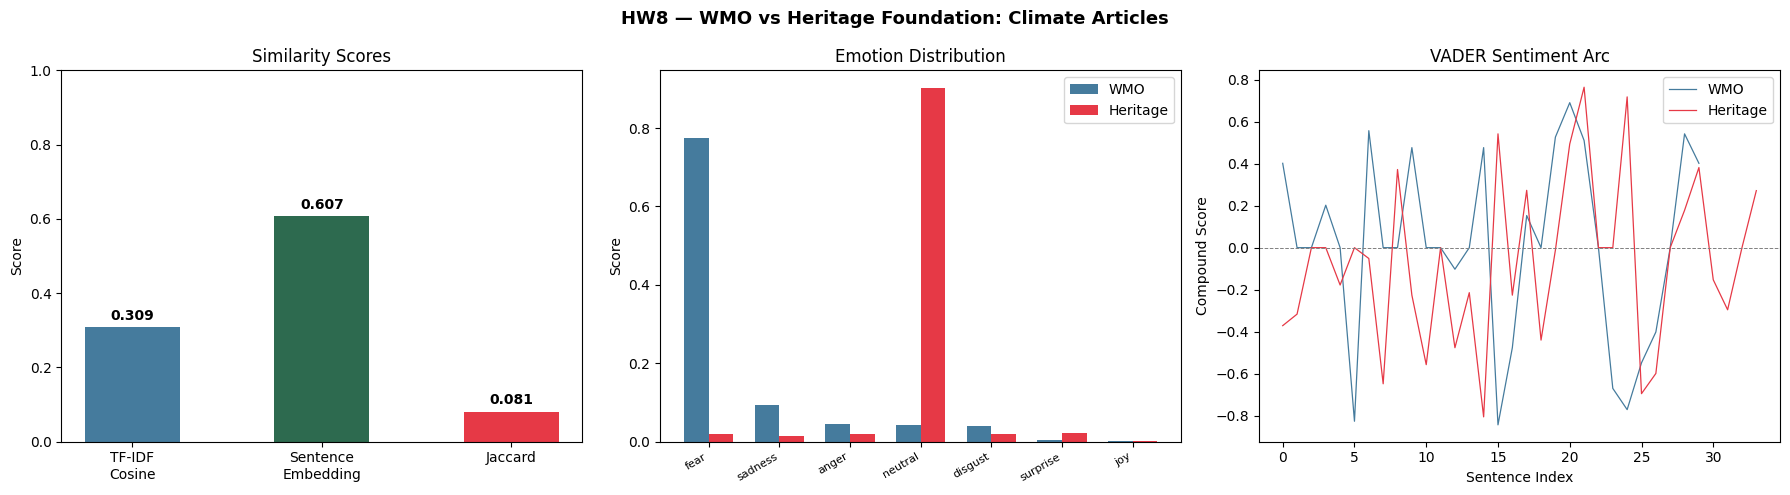

Saved: hw8_analysis.png


In [13]:
#  Visualizations ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('HW8 — WMO vs Heritage Foundation: Climate Articles', fontsize=13, fontweight='bold')

# ── Plot 1: Similarity Bar Chart ──
methods = ['TF-IDF\nCosine', 'Sentence\nEmbedding', 'Jaccard']
scores  = [cosine_sim, semantic_sim, jaccard_sim]
bars    = axes[0].bar(methods, scores, color=['#457b9d', '#2d6a4f', '#e63946'], width=0.5)
axes[0].set_ylim(0, 1)
axes[0].set_title('Similarity Scores')
axes[0].set_ylabel('Score')
for bar, score in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{score:.3f}', ha='center', fontsize=10, fontweight='bold')

# ── Plot 2: Emotion Grouped Bar Chart ──
emotions = list(nyt_dict.keys())
nyt_vals = [nyt_dict[e] for e in emotions]
fox_vals = [fox_dict.get(e, 0) for e in emotions]
x = np.arange(len(emotions))
w = 0.35
axes[1].bar(x - w/2, nyt_vals, w, label='WMO',      color='#457b9d')
axes[1].bar(x + w/2, fox_vals, w, label='Heritage',  color='#e63946')
axes[1].set_xticks(x)
axes[1].set_xticklabels(emotions, rotation=30, ha='right', fontsize=8)
axes[1].set_title('Emotion Distribution')
axes[1].set_ylabel('Score')
axes[1].legend()

# ── Plot 3: VADER Sentiment Arc ──
nyt_arc = [s['compound'] for s in nyt_sent_scores]
fox_arc = [s['compound'] for s in fox_sent_scores]
axes[2].plot(nyt_arc, color='#457b9d', linewidth=0.9, label='WMO')
axes[2].plot(fox_arc, color='#e63946', linewidth=0.9, label='Heritage')
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.7)
axes[2].set_title('VADER Sentiment Arc')
axes[2].set_xlabel('Sentence Index')
axes[2].set_ylabel('Compound Score')
axes[2].legend()

plt.tight_layout()
plt.savefig('hw8_analysis.png', dpi=150)
plt.show()
print("Saved: hw8_analysis.png")